# Imputation of time-series using a custom architecture based on CSDI

In [1]:
!nvidia-smi

Tue Jun  2 14:35:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.20             Driver Version: 580.126.20     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 4500 Blac...    On  |   00000000:82:00.0 Off |                  Off |
| 30%   23C    P8             12W /  200W |       2MiB /  32623MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
# Libraries imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import datetime
import json
import yaml
import os
import sys

# Our code import
sys.path.append("..")
sys.path.append(os.path.abspath("../models"))

from models.custom_main import Custom_CSDI_WaterQual
from utils import *
from dataset_ope import get_dataloader

In [3]:
# Set seed
rng = np.random.RandomState(1)

## Load Data

In [4]:
#Load all data on GPU, will run on cpu without modification if gpu is not available

gpu = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_loader, valid_loader, test_loader, _, _ = get_dataloader('../data/ope_andra/hydrology_sagd_training_data_50_hte.csv',
                                                               path_covariate_data='../data/ope_andra/safran_covariates.csv',
                                                               device=gpu,
                                                               batch_size=8)

Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Training dataset len:  4279
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Valid dataset len:  20
Loaded SAGD training data with shape:  (25981, 75)
Loaded SAGD training mask with shape:  (25981, 75)
Loaded covariates with shape:  (25981, 72)
Test dataset len:  28


## Model Definition and Training

In [5]:
data_dim = 75

In [6]:
# Load the config

# My own config for cigeo
path = "../config/water_quality_imputation.yaml"

with open(path, "r") as f:
    config = yaml.safe_load(f)

# The only thing I overwrite, so I can change epochs for my tests
config["train"]["epochs"] = 100

current_time = datetime.datetime.now().strftime("%Y%m%d_%H%M%S") 
foldername = (
    "./save/validationindex" + "_" + current_time
)

os.makedirs(foldername, exist_ok=True)
with open(foldername + "config.json", "w") as f:
    json.dump(config, f, indent=4)


In [7]:
from models.custom_main import Custom_CSDI_WaterQual

device = torch.device("cuda")
model = Custom_CSDI_WaterQual(config, "cuda:0", target_dim=data_dim).to("cuda:0")

/workspace/last_last_version/notebooks/../models/custom_architecture.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  return nn.TransformerEncoder(encoder_layer, num_layers=layers)


In [8]:
do_train = False

if do_train:
# define and train mode. keep an history for monitoring
    history  = {}

    # It returns history, which we don't need really
    _ = train(
        model,
        config["train"],
        train_loader,
        valid_loader=valid_loader,
        foldername=foldername,
        history=history)

In [9]:
if do_train:
    torch.save(model.state_dict(), "../saved_weights/custom_model_weights.pt")
else:
    model.load_state_dict(torch.load("../saved_weights/custom_model_weights.pt", weights_only=True))
    model.to(device)

In [10]:
param_size = 0
for param in model.parameters():
    param_size += param.nelement() * param.element_size()
buffer_size = 0
for buffer in model.buffers():
    buffer_size += buffer.nelement() * buffer.element_size()

size_all_mb = (param_size + buffer_size) / 1024**2
print('model size: {:.3f}MB'.format(size_all_mb))


model size: 4.958MB


## Evaluations and Tests

### Single generation test

In [11]:
from utils import plot_single_imputation_results

In [12]:
# Load next batch manually
batch = next(iter(test_loader))

device = model.device
observed_mask = batch['observed_mask'].to(device, dtype=torch.float32)
observed_data = batch['observed_data'].to(device, dtype=torch.float32)
timestamps = batch['timepoints'].to(device)  # Souvent nécessaire pour le modèle

observed_mask_forecast = observed_mask.clone()
observed_mask_forecast[:, 25:] = 0.

observed_data_masked = observed_data * observed_mask_forecast

with torch.no_grad():
    generated = model.impute(
        observed_data_masked, 
        observed_mask_forecast, 
        n_samples=1, 
        timestamps=timestamps
    )

/workspace/last_last_version/notebooks/../models/custom_main.py:260: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  observed_tp = torch.tensor(observed_tp, dtype=torch.float32).to(self.device)


In [17]:
print(type(batch['observed_mask']))
print("\n")
print(batch['observed_mask'].dtype)
print("\n")
print(batch['observed_mask'].shape)
print("\n")
print(batch['observed_mask'][0, :5, 0])

<class 'torch.Tensor'>


torch.int64


torch.Size([8, 24, 75])


tensor([0, 0, 0, 0, 0])


In [18]:
print(type(batch['observed_data']))
print("\n")
print(batch['observed_data'].dtype)
print("\n")
print(batch['observed_data'].shape)
print("\n")
print(batch['observed_data'][0, :5, 0])

<class 'torch.Tensor'>


torch.float64


torch.Size([8, 24, 75])


tensor([-0.1326, -0.1326, -0.1326, -0.1326, -0.1326], dtype=torch.float64)


In [21]:
print(type(observed_mask))
print("\n\n")
print(observed_mask.dtype)
print("\n\n")
print(observed_mask.shape)
print("\n\n")
print(observed_mask[0, :5, 0])

<class 'torch.Tensor'>



torch.float32



torch.Size([8, 24, 75])



tensor([0., 0., 0., 0., 0.], device='cuda:0')


In [22]:
print(type(observed_data))
print("\n\n")
print(observed_data.dtype)
print("\n\n")
print(observed_data.shape)
print("\n\n")
print(observed_data[0, :5, 0])

<class 'torch.Tensor'>



torch.float32



torch.Size([8, 24, 75])



tensor([-0.1326, -0.1326, -0.1326, -0.1326, -0.1326], device='cuda:0')


In [20]:
print(type(generated))
print("\n\n")
print(generated.dtype)
print("\n\n")
print(generated.shape)
print("\n\n")
print(generated[0, :5, 0])

<class 'torch.Tensor'>



torch.float32



torch.Size([8, 1, 75, 24])



tensor([[0.2841, 0.2387, 0.3214, 0.3577, 0.3681, 0.3949, 0.6648, 0.4675, 0.4386,
         0.2340, 0.2844, 0.2561, 0.3819, 0.5099, 0.4719, 0.4525, 0.3973, 0.4482,
         0.4278, 0.5749, 0.5762, 0.4737, 0.4685, 0.5125]], device='cuda:0')


In [13]:
# Bring back the data on the cpu for vizualization

generated_test = generated.cpu().permute([0, 1, 3, 2]).numpy()[0].squeeze()
observations = observed_data[0].squeeze().cpu().numpy()
mask = observed_mask_forecast[0].squeeze().cpu().numpy()
timestamps = batch['timepoints'][0].squeeze().numpy()

generated_test.shape, observations.shape, mask.shape, timestamps.shape

((24, 75), (24, 75), (24, 75), (24,))

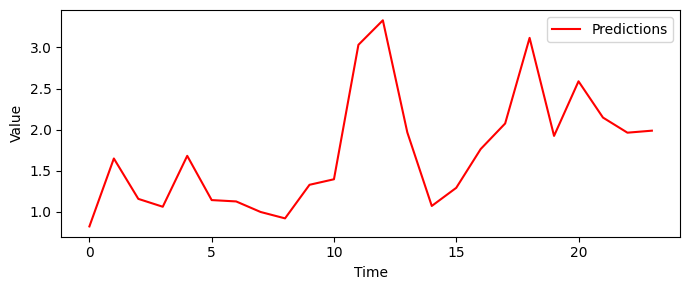

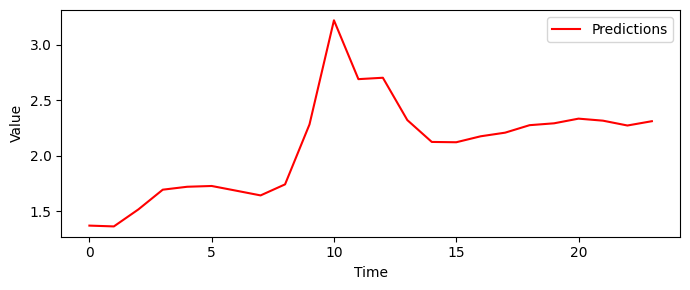

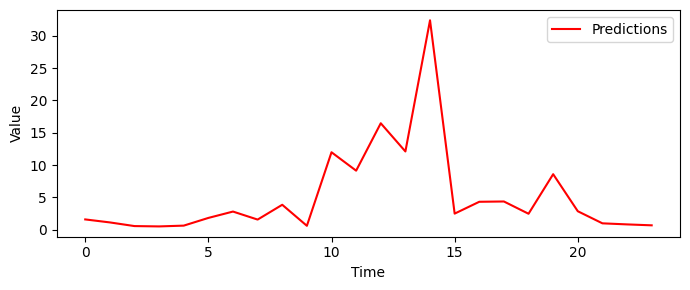

In [14]:
plot_single_imputation_results(generated_test, mask)

## Evaluate Forecasting

### Forecasting Metrics

In [ ]:
import numpy as np
from collections import defaultdict

horizons = [6, 12, 18]
n_trials = 5

results = {h: defaultdict(list) for h in horizons}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for h in horizons:
        out = evaluate_forecasting(
            model,
            test_loader,
            prediction_horizon=h,
            nsample=100,
            foldername=foldername
        )
        
        for key, value in out.items():
            results[h][key].append(value)

# Compute mean & std over trials
print("\n=== Forecasting Results ===")
for h in horizons:
    print(f"\nHorizon: {h}")
    
    for metric in results[h]:
        values = np.array(results[h][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

### Forecasting Visualization

In [15]:
batch = next(iter(test_loader))

device = model.device
observed_mask = batch['observed_mask'].to(device, dtype=torch.float32)
real_data = batch['observed_data'].to(device, dtype=torch.float32)
timestamps = batch['timepoints'].to(device)  # Souvent nécessaire pour le modèle

observed_mask_forecast = observed_mask.clone()
observed_mask_forecast[:, 18:] = 0.

observed_data_masked = observed_data * observed_mask_forecast

with torch.no_grad():
    generated = model.impute(real_data, observed_mask_forecast, n_samples=100, timestamps=batch['timepoints'])

(<Figure size 3000x2000 with 80 Axes>,
 array([[<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >

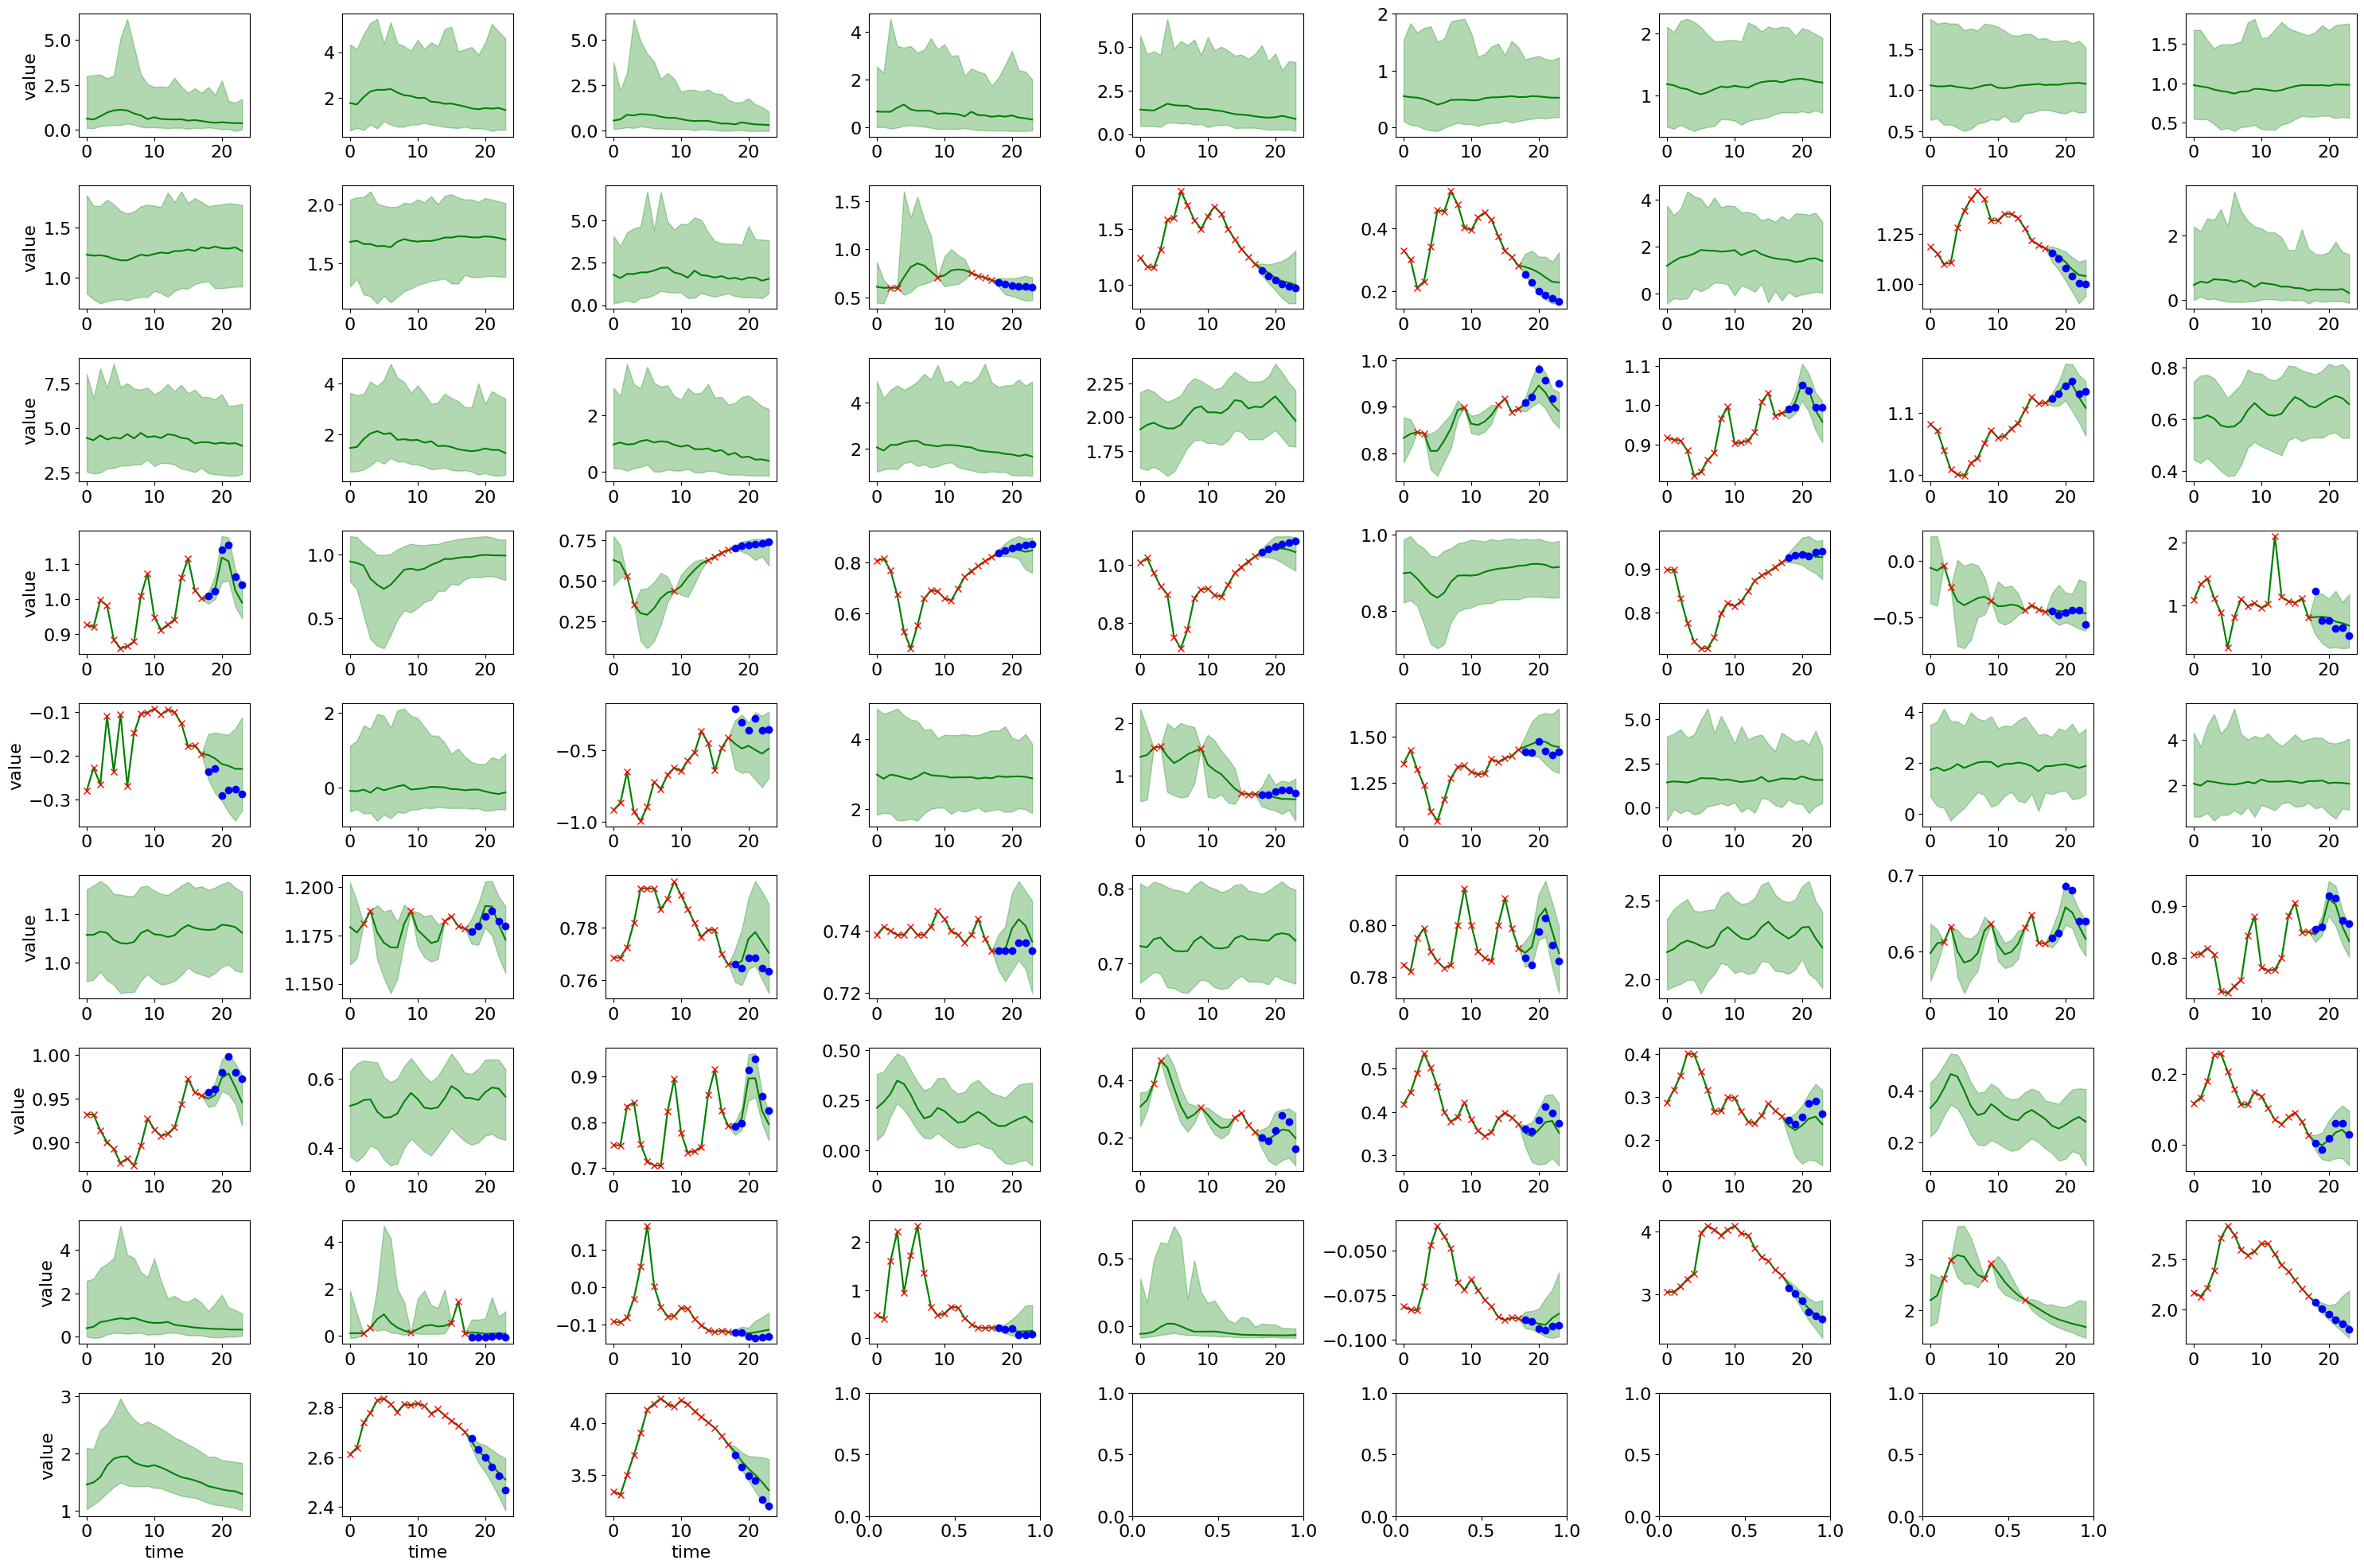

In [17]:
dataind = 4 # Modify to visualize a different realization
multivariate_visualize(dataind, generated, real_data, observed_mask, observed_mask_forecast)

## Evaluate Imputation

### Imputation Metrics

In [ ]:
import numpy as np
from collections import defaultdict

ratios = [0.25, 0.50, 0.75, 0.90]
n_trials = 5

results = {r: defaultdict(list) for r in ratios}

# Run trials
for trial in range(n_trials):
    print(f"Trial {trial+1}/{n_trials}")
    
    for seed, r in enumerate(ratios):
        out = evaluate_imputation(
            model,
            test_loader,
            ratio_missing=r,
            nsample=100,
            seed=seed,
            foldername=foldername
        )
        
        for key, value in out.items():
            results[r][key].append(value)

# Compute mean & std over trials
print("\n=== Imputation Results ===")
for r in ratios:
    print(f"\nMissing Ratio: {r}")
    
    for metric in results[r]:
        values = np.array(results[r][metric])
        mean = values.mean()
        std = values.std()
        
        print(f"{metric}: {mean:.4f} ± {std:.4f}")

### Imputation Visualization

In [18]:
# We only need one batch, so fetch it directly without a full loop
batch = next(iter(test_loader))

observed_mask = batch['observed_mask']
real_data = batch['observed_data']

# Calculate exact number of timesteps to retain
ratio_to_keep = 0.45  # 55% missing
num_timesteps = observed_mask.shape[1]
timesteps_to_keep = int(ratio_to_keep * num_timesteps)

# Vectorized random masking: Generate random noise matching the time and channel dimensions
# & find the threshold value for each channel to keep exactly the top 'timesteps_to_keep'
noise = torch.rand(observed_mask.shape[1], observed_mask.shape[2], device=observed_mask.device)
thresholds = torch.topk(noise, k=timesteps_to_keep, dim=0).values[-1, :]

# Create the imputation mask entirely in PyTorch
random_mask = noise >= thresholds
observed_mask_imputation = observed_mask * random_mask.unsqueeze(0)

# Prepare inputs for the model
observed_data = real_data * observed_mask_imputation

observed_mask_imputation = observed_mask_imputation.to(model.device).float()
observed_data = observed_data.to(model.device).float()

# Inference
with torch.no_grad():
    generated = model.impute(
        observed_data, 
        observed_mask_imputation, 
        n_samples=100, 
        timestamps=batch['timepoints']
    )

(<Figure size 3000x2000 with 80 Axes>,
 array([[<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: ylabel='value'>, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
         <Axes: >, <Axes: >

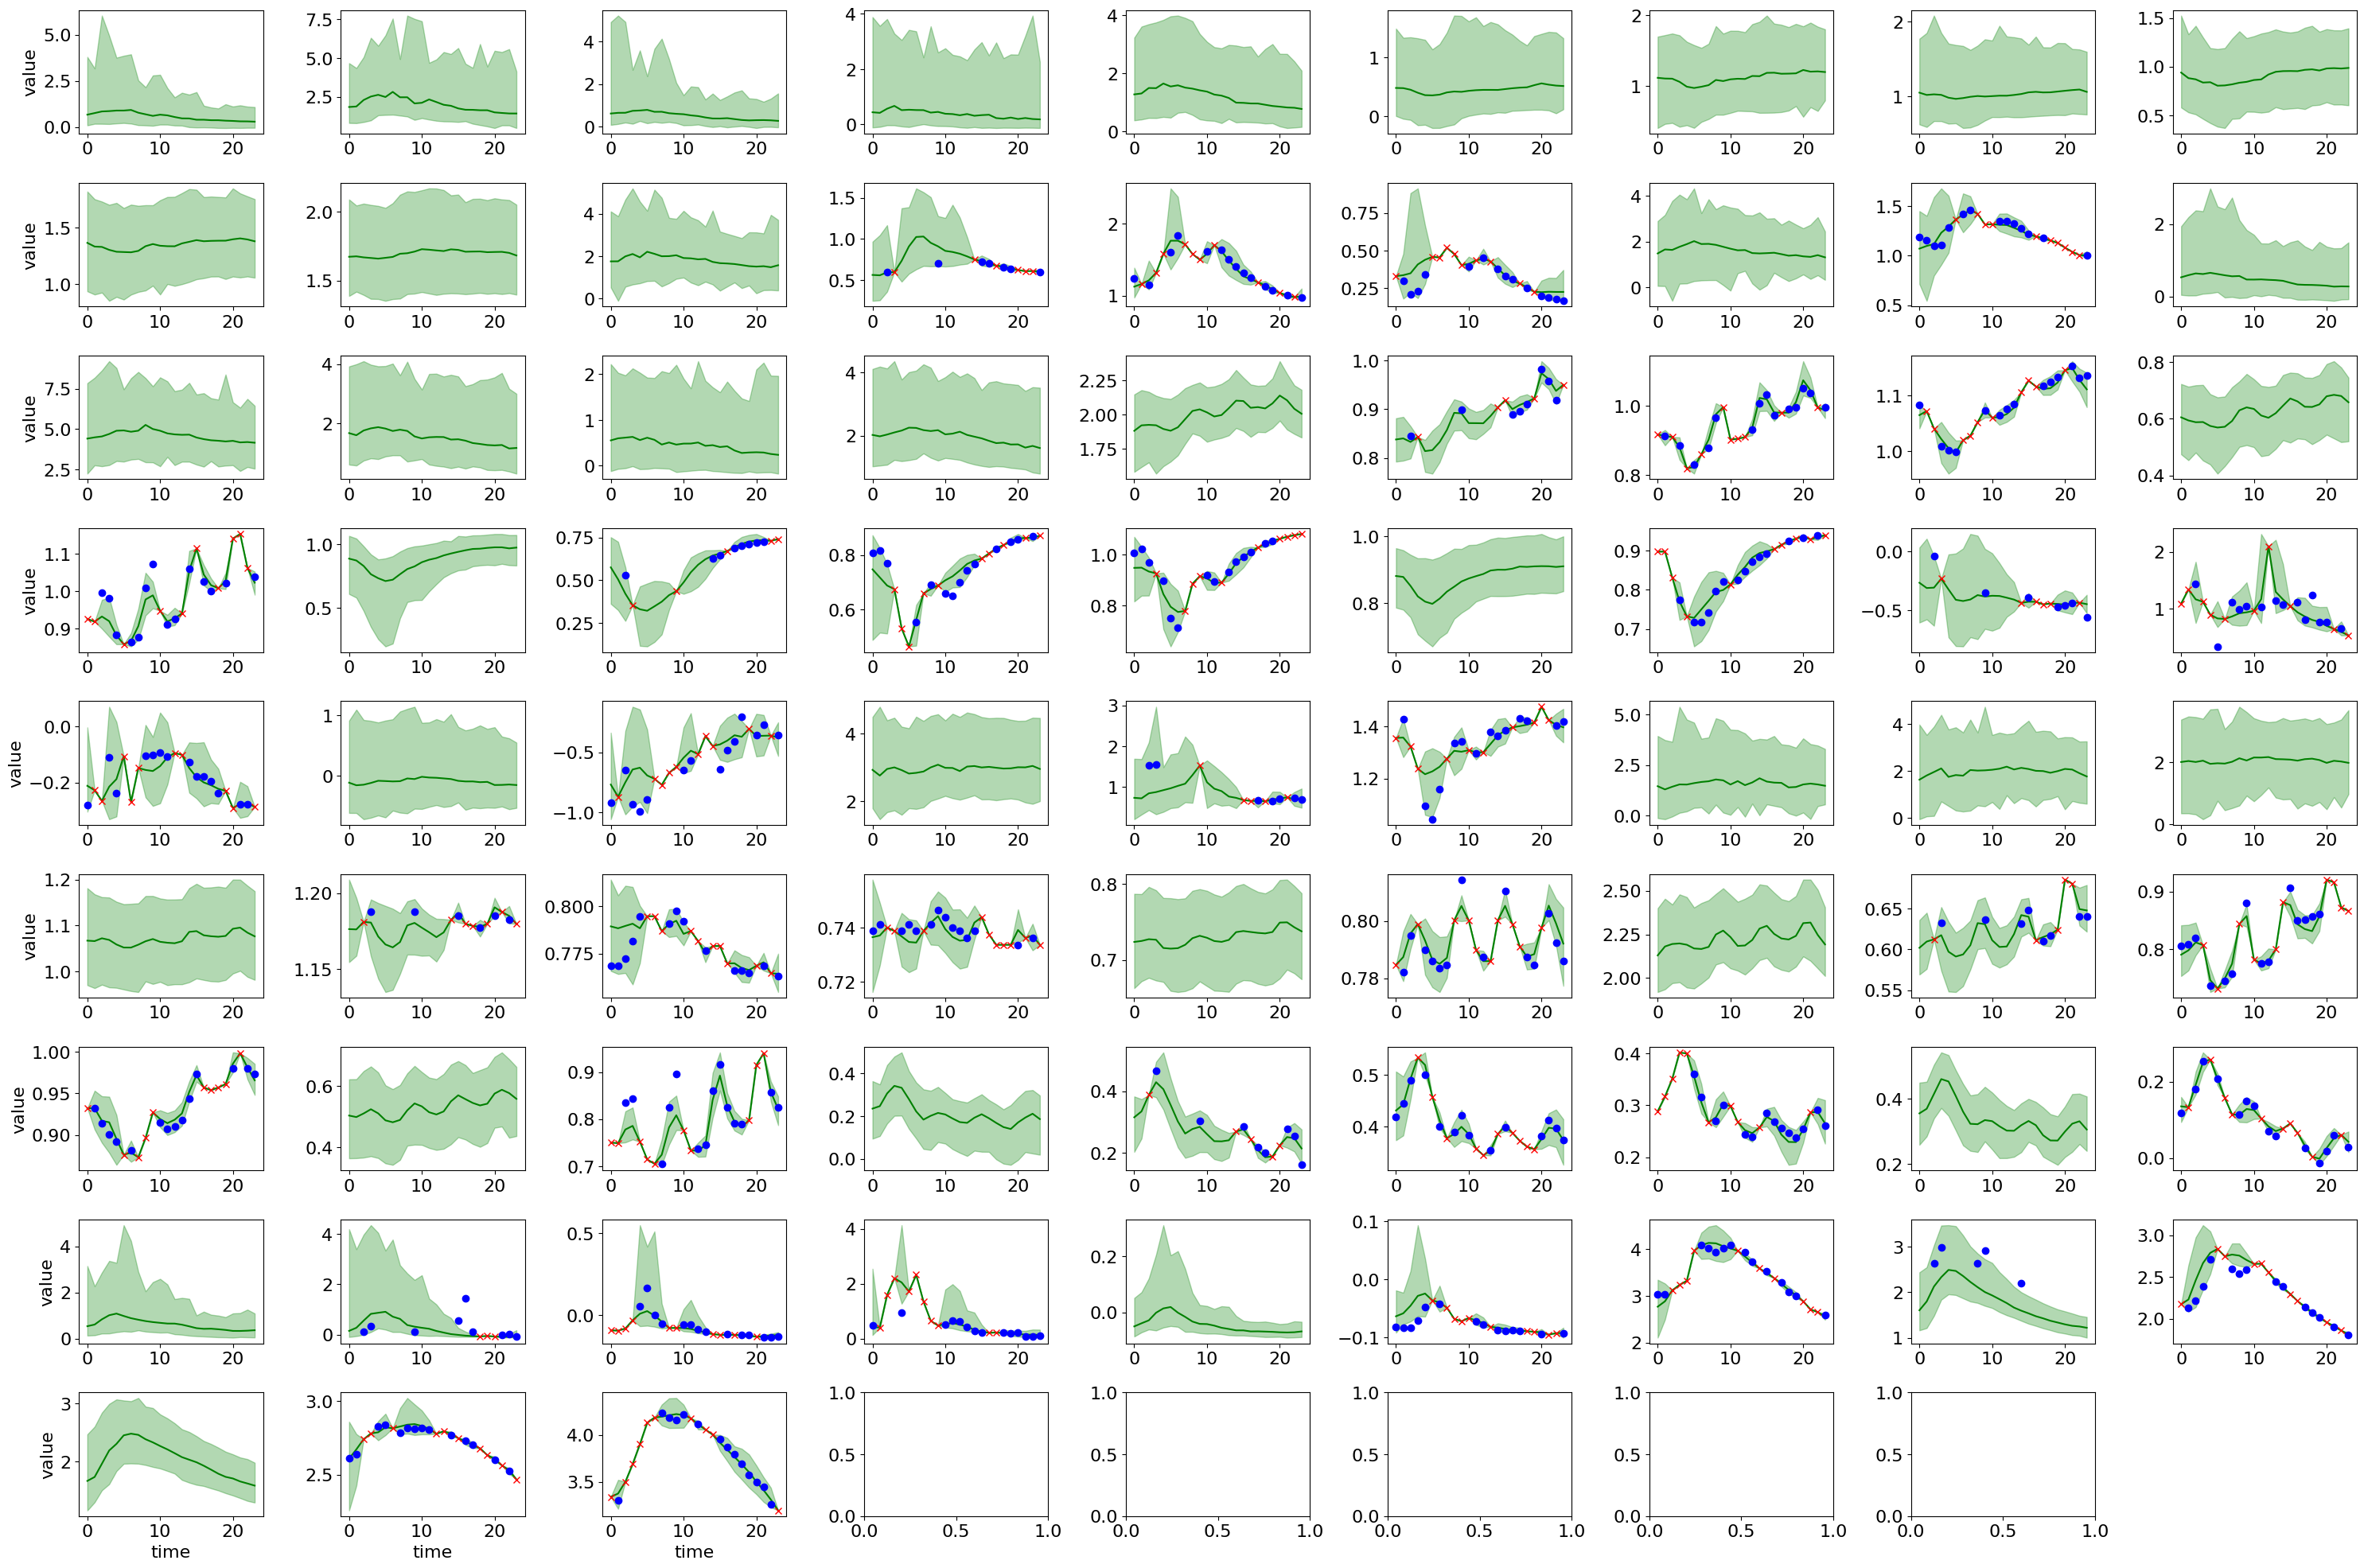

In [20]:
multivariate_visualize(dataind, generated, real_data, observed_mask, observed_mask_imputation)